# Tahap 5 — Atribusi Shapley Temporal dengan WindowSHAP

Mengikuti Subbab 2.2.7 dan 3.6.5 naskah proposal. Dua tujuan:

1. **Memverifikasi implementasi** [`src/windowshap.py`](../src/windowshap.py) terhadap kasus yang
   nilai Shapley-nya diketahui secara analitik, bukan sekadar memastikan kodenya berjalan.
2. **Merekalibrasi ambang keselarasan dengan phi**, bukan alpha. Skenario S1 menghasilkan ambang
   berbasis bobot atensi karena WindowSHAP belum ada saat itu, sementara analisis primer pada
   Subbab 3.6.7 menuntut phi. Menghitung ulang dengan rumus yang sama pada besaran yang benar
   bukan penyesuaian pasca-hasil, melainkan penyelesaian yang memang tertunda.

Sepanjang notebook ini, phi selalu dihitung pada grid jendela yang **dikunci sama** dengan grid
patch model, sehingga phi dan alpha dapat dibandingkan tanpa penyelarasan ulang.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import NullFormatter, NullLocator
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import StratifiedGroupKFold

from preprocessing import muat_cache, Normalisasi
from injection import suntik_tremor
from model import PDClassifier
from training import latih, prediksi, metrik_biner
from windowshap import WindowSHAP
from metrics import ringkas_lokalisasi
from viz import WARNA, TINTA, pasang_gaya, rapikan, pita_tremor

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
FS, P = 100, 14
EPOCHS = 80
AMPLITUDO = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
SEED = 0
N_KOALISI = 2048          # dipilih dari kalibrasi kestabilan pada Bagian 3
LATAR_UTAMA = "nol"
LATAR_ABLASI = "median_lokal"

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s6_artefak_phi.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
hc = [r for r in rek if r.kelompok == "HC"]
print(f"perangkat: {DEV} | patch P={P} ({P*10} ms) | koalisi: {N_KOALISI}")
print(f"rekaman kontrol sehat: {len(hc)} dari {len(set(r.subjek for r in hc))} subjek")

def sumbu_amplitudo(ax, x):
    ax.set_xscale("log"); ax.set_xticks(x); ax.set_xticklabels([f"{v:g}" for v in x])
    ax.xaxis.set_minor_locator(NullLocator()); ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlim(x[0] * 0.7, x[-1] * 1.5); ax.set_xlabel("amplitudo injeksi (piksel)")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch P=14 (140 ms) | koalisi: 2048
rekaman kontrol sehat: 37 dari 15 subjek


## 1. Verifikasi implementasi terhadap jawaban analitik

Menjalankan tanpa galat bukan bukti benar. Untuk **fungsi aditif**, nilai Shapley memiliki bentuk
tertutup: kontribusi tiap jendela sama dengan sumbangannya sendiri. Implementasi yang benar harus
memulihkan angka itu, bukan sekadar menghasilkan sesuatu yang terlihat masuk akal.

Diuji pula **aksioma efisiensi**: jumlah seluruh nilai Shapley harus persis sama dengan selisih
keluaran pada masukan utuh dan pada latar penuh. Kendala ini ditegakkan secara aljabar oleh pemecah,
sehingga sisa yang tidak nol menandakan kekeliruan implementasi.

In [2]:
P_UJI, W_UJI = 10, 12
T_UJI, C_UJI = P_UJI * W_UJI, 3
bobot = np.arange(1.0, W_UJI + 1)

def fungsi_aditif(x, lengths):
    xn = x.detach().cpu().numpy()
    nilai = [(xn[b, :T_UJI, 0].reshape(W_UJI, P_UJI).mean(1) * bobot).sum() for b in range(len(xn))]
    return torch.tensor(nilai, dtype=torch.float32, device=x.device)

rng = np.random.default_rng(0)
x_uji = rng.normal(size=(T_UJI, C_UJI)).astype(np.float32)
phi_eksak = x_uji[:, 0].reshape(W_UJI, P_UJI).mean(1) * bobot

ws_uji = WindowSHAP(fungsi_aditif, patch_size=P_UJI, n_koalisi=4000, batch=256, device="cpu", seed=0)
h_uji = ws_uji.explain(x_uji)

galat = float(np.abs(h_uji.phi - phi_eksak).max())
efis = ws_uji.periksa_efisiensi(x_uji)
print(f"galat maks terhadap nilai eksak : {galat:.3e}   {'LOLOS' if galat < 1e-3 else 'GAGAL'}")
print(f"korelasi phi terhadap eksak     : {np.corrcoef(h_uji.phi, phi_eksak)[0,1]:.6f}")
print(f"r2 regresi (harus ~1 utk aditif): {h_uji.r2:.6f}")
print(f"aksioma efisiensi, sisa         : {efis['sisa']:.3e}   {'LOLOS' if efis['lolos'] else 'GAGAL'}")

galat maks terhadap nilai eksak : 9.049e-06   LOLOS
korelasi phi terhadap eksak     : 1.000000
r2 regresi (harus ~1 utk aditif): 1.000000
aksioma efisiensi, sisa         : 0.000e+00   LOLOS


### Gambar 1 — Pemulihan nilai eksak pada fungsi aditif

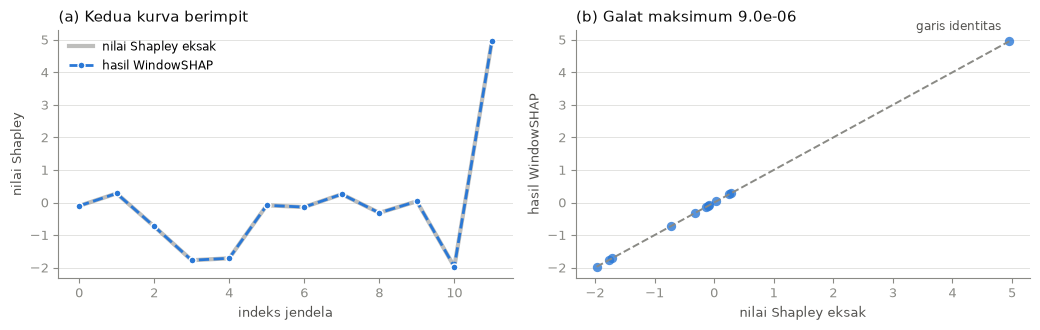

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))

ax = axes[0]; rapikan(ax)
j = np.arange(W_UJI)
ax.plot(j, phi_eksak, "-", color=WARNA["netral"], lw=3, alpha=0.55, label="nilai Shapley eksak")
ax.plot(j, h_uji.phi, "--", color=WARNA["biru"], marker="o", markersize=5,
        markeredgecolor="white", markeredgewidth=1, label="hasil WindowSHAP")
ax.set_xlabel("indeks jendela"); ax.set_ylabel("nilai Shapley")
ax.set_title("(a) Kedua kurva berimpit", loc="left"); ax.legend(fontsize=8.5)

ax = axes[1]; rapikan(ax)
ax.scatter(phi_eksak, h_uji.phi, s=45, color=WARNA["biru"], alpha=0.8, lw=0)
lim = [min(phi_eksak.min(), h_uji.phi.min()), max(phi_eksak.max(), h_uji.phi.max())]
ax.plot(lim, lim, ls="--", color=WARNA["netral"], lw=1.4)
ax.annotate("garis identitas", xy=(lim[1], lim[1]), xytext=(-6, 8), textcoords="offset points",
            ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("nilai Shapley eksak"); ax.set_ylabel("hasil WindowSHAP")
ax.set_title(f"(b) Galat maksimum {galat:.1e}", loc="left")
plt.tight_layout(); plt.show()

## 2. Perilaku pada sinyal redundan

Subbab 2.2.7 menyatakan keterbatasan yang diakui: nilai Shapley membagi kredit di antara fitur yang
berkorelasi. Pada rancangan ini tremor tersebar di banyak jendela berdekatan, sehingga menghapus
satu jendela saja mungkin nyaris tidak mengubah keluaran, dan atribusinya berpotensi terbagi tipis.

Kekhawatiran itu diuji langsung dengan tiga struktur fungsi yang lokasi sinyalnya identik namun
cara jendela-jendelanya berinteraksi berbeda:

| Struktur | Arti |
|---|---|
| aditif | tiap jendela menyumbang mandiri |
| maksimum | **redundan** — satu jendela saja sudah cukup |
| minimum | komplementer — seluruh jendela harus hadir |

In [4]:
P_R, W_R = 10, 20
T_R = P_R * W_R
JEND = slice(6, 14)
acuan_r = np.zeros(W_R); acuan_r[JEND] = 1

def buat_fungsi(mode):
    def f(x, lengths):
        xn = x.detach().cpu().numpy(); keluar = []
        for b in range(len(xn)):
            pj = xn[b, :T_R, 0].reshape(W_R, P_R).mean(1)[JEND]
            keluar.append({"aditif": pj.sum, "maksimum": pj.max, "minimum": pj.min}[mode]() * 5)
        return torch.tensor(keluar, dtype=torch.float32, device=x.device)
    return f

rng = np.random.default_rng(1)
x_r = np.zeros((T_R, 3), dtype=np.float32)
x_r[:, 0] = rng.normal(0, 0.1, T_R)
x_r[JEND.start * P_R : JEND.stop * P_R, 0] += 2.0

hasil_r, phi_r = [], {}
for mode in ["aditif", "maksimum", "minimum"]:
    ws = WindowSHAP(buat_fungsi(mode), patch_size=P_R, n_koalisi=6000, batch=256, device="cpu", seed=0)
    h = ws.explain(x_r)
    phi_r[mode] = h.phi
    m = ringkas_lokalisasi(h.phi_positif, acuan_r)
    hasil_r.append({"struktur": mode, "massa": m["massa"], "rank_accuracy": m["rank_accuracy"],
                    "pointing_game": m["pointing_game"], "maks_abs_phi": float(np.abs(h.phi).max()),
                    "r2": h.r2})
df_r = pd.DataFrame(hasil_r).set_index("struktur")
display(df_r.round(3))
print(f"pembanding netral massa (lebar wilayah acuan) = {acuan_r.mean():.3f}")

,massa,rank_accuracy,pointing_game,maks_abs_phi,r2
struktur,,,,,
aditif,1.000,1.0,1.0,10.080,1.000
maksimum,0.956,1.0,1.0,1.349,-1.052
minimum,0.955,1.0,1.0,1.318,-1.086


pembanding netral massa (lebar wilayah acuan) = 0.400


### Gambar 2 — Redundansi menggerus besaran, bukan lokasi

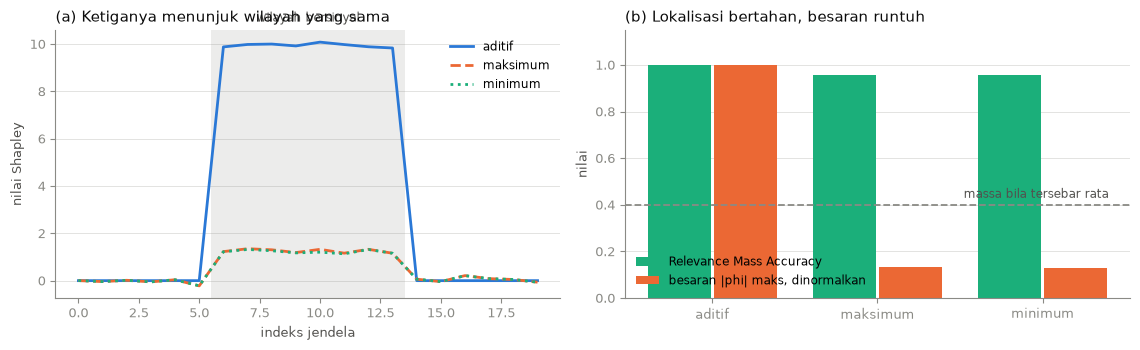

r2 pada struktur redundan dan komplementer bernilai NEGATIF (-1.05 dan -1.09).
Itu bukan kegagalan implementasi melainkan diagnostik yang benar: r2 mengukur seberapa
aditif model bila dipandang dari jendela-jendelanya. Pada fungsi maksimum dan minimum,
model memang sama sekali tidak aditif, sehingga pengganti linear berkendala efisiensi
mencocokkan lebih buruk daripada sekadar menebak rata-rata. Nilai Shapley-nya tetap sah;
yang runtuh adalah kemampuan SATU model linear meringkasnya.

Besaran |phi| maksimum turun 7.5 kali lipat saat sinyal menjadi redundan,
namun Relevance Mass Accuracy bertahan di 0.955 terhadap pembanding netral 0.400.

Kesimpulan: pembagian kredit yang dikhawatirkan Subbab 2.2.7 memang terjadi, tetapi
menggerus BESARAN, bukan LOKASI. Karena metrik lokalisasi bersifat invarian terhadap
skala, redundansi tidak membatalkan analisis keselarasan. Ia hanya melarang penafsiran
besaran phi absolut sebagai ukuran kepentingan.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax = axes[0]; rapikan(ax)
j = np.arange(W_R)
for mode, warna, gaya in [("aditif", WARNA["biru"], "-"),
                          ("maksimum", WARNA["jingga"], "--"),
                          ("minimum", WARNA["toska"], ":")]:
    ax.plot(j, phi_r[mode], gaya, color=warna, lw=2, label=mode)
ax.axvspan(JEND.start - 0.5, JEND.stop - 0.5, color=WARNA["netral"], alpha=0.16, lw=0)
ax.annotate("wilayah bersinyal", xy=(0.5, 1.02), xycoords="axes fraction",
            ha="center", va="bottom", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("indeks jendela"); ax.set_ylabel("nilai Shapley")
ax.set_title("(a) Ketiganya menunjuk wilayah yang sama", loc="left"); ax.legend(fontsize=8.5)

ax = axes[1]; rapikan(ax)
posisi = np.arange(len(df_r))
ax.bar(posisi - 0.2, df_r.massa, width=0.38, color=WARNA["toska"], label="Relevance Mass Accuracy")
ax.bar(posisi + 0.2, df_r.maks_abs_phi / df_r.maks_abs_phi.max(), width=0.38,
       color=WARNA["jingga"], label="besaran |phi| maks, dinormalkan")
ax.axhline(acuan_r.mean(), color=WARNA["netral"], ls="--", lw=1.3)
ax.annotate("massa bila tersebar rata", xy=(len(df_r) - 0.6, acuan_r.mean()), xytext=(0, 5),
            textcoords="offset points", ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(posisi); ax.set_xticklabels(df_r.index)
ax.set_ylabel("nilai"); ax.set_ylim(0, 1.15)
ax.set_title("(b) Lokalisasi bertahan, besaran runtuh", loc="left"); ax.legend(fontsize=8.5, loc="lower left")
plt.tight_layout(); plt.show()

turun = df_r.maks_abs_phi["aditif"] / df_r.maks_abs_phi["maksimum"]
print(f"r2 pada struktur redundan dan komplementer bernilai NEGATIF ({df_r.r2['maksimum']:.2f} dan {df_r.r2['minimum']:.2f}).")
print("Itu bukan kegagalan implementasi melainkan diagnostik yang benar: r2 mengukur seberapa")
print("aditif model bila dipandang dari jendela-jendelanya. Pada fungsi maksimum dan minimum,")
print("model memang sama sekali tidak aditif, sehingga pengganti linear berkendala efisiensi")
print("mencocokkan lebih buruk daripada sekadar menebak rata-rata. Nilai Shapley-nya tetap sah;")
print("yang runtuh adalah kemampuan SATU model linear meringkasnya.")
print()
print(f"Besaran |phi| maksimum turun {turun:.1f} kali lipat saat sinyal menjadi redundan,")
print(f"namun Relevance Mass Accuracy bertahan di {df_r.massa.min():.3f} terhadap pembanding netral {acuan_r.mean():.3f}.")
print()
print("Kesimpulan: pembagian kredit yang dikhawatirkan Subbab 2.2.7 memang terjadi, tetapi")
print("menggerus BESARAN, bukan LOKASI. Karena metrik lokalisasi bersifat invarian terhadap")
print("skala, redundansi tidak membatalkan analisis keselarasan. Ia hanya melarang penafsiran")
print("besaran phi absolut sebagai ukuran kepentingan.")

## 3. Kalibrasi anggaran koalisi dan strategi latar

Dua parameter yang harus ditetapkan sebelum dipakai, dan keduanya ditetapkan dari pengukuran.

**Anggaran koalisi** menentukan seberapa stabil estimasinya. Diuji dengan menjalankan estimasi
berulang memakai seed cuplikan berbeda pada rekaman yang sama: bila stabil, urutan jendelanya tidak
berubah antar pengulangan.

**Strategi latar** menentukan makna "fitur tidak hadir". Subbab 3.6.5 menuntut satu pilihan
ditetapkan dan diargumentasikan, disertai satu ablasi.

In [6]:
stcp = [r for r in rek if r.tugas == 2]
norm_demo = Normalisasi().fit(rek)
torch.manual_seed(SEED)
model_demo = PDClassifier(encoder="mamba2", patch_size=P).to(DEV).eval()
f_demo = lambda x, l: model_demo(x, l)[0]
x_demo = norm_demo.transform(stcp[0].kanal)

baris = []
for nk in [512, 1024, 2048, 4096]:
    kumpul, t0 = [], time.time()
    for s in range(3):
        kumpul.append(WindowSHAP(f_demo, patch_size=P, n_koalisi=nk, batch=128,
                                 device=DEV, seed=s).explain(x_demo).phi)
    dt = (time.time() - t0) / 3
    pasang = [(0, 1), (0, 2), (1, 2)]
    baris.append({"n_koalisi": nk,
                  "spearman_antar_seed": float(np.mean([spearmanr(kumpul[i], kumpul[j]).statistic for i, j in pasang])),
                  "pearson_antar_seed": float(np.mean([pearsonr(kumpul[i], kumpul[j])[0] for i, j in pasang])),
                  "detik_per_rekaman": dt})
stabil = pd.DataFrame(baris).set_index("n_koalisi")
display(stabil.round(4))
print(f"Dipilih n_koalisi = {N_KOALISI}: kestabilan antar seed di atas 0,99 dengan biaya di bawah satu detik.")

,spearman_antar_seed,pearson_antar_seed,detik_per_rekaman
n_koalisi,,,
512,0.9571,0.9814,1.7537
1024,0.9737,0.9908,0.2305
2048,0.9896,0.9961,0.4680
4096,0.9953,0.9984,0.9156


Dipilih n_koalisi = 2048: kestabilan antar seed di atas 0,99 dengan biaya di bawah satu detik.


In [7]:
baris = []
for strategi in ["nol", "median_lokal"]:
    h = WindowSHAP(f_demo, patch_size=P, strategi_latar=strategi, n_koalisi=N_KOALISI,
                   batch=128, device=DEV, seed=SEED).explain(x_demo)
    baris.append({"strategi": strategi, "r2": h.r2, "maks_abs_phi": float(np.abs(h.phi).max()),
                  "frac_positif": float((h.phi > 0).mean()), "phi_0": h.phi_0})
latar_df = pd.DataFrame(baris).set_index("strategi")
display(latar_df.round(4))

,r2,maks_abs_phi,frac_positif,phi_0
strategi,,,,
nol,0.7572,0.0091,0.8158,0.1153
median_lokal,0.9695,0.0030,0.5263,0.1783


**Pilihan yang ditetapkan: latar `nol`.** Setelah normalisasi robust, nilai nol
mendekati median himpunan latih, sehingga mengganti sebuah jendela dengan nol berarti menggantinya
dengan "nilai yang lazim menurut data latih". Acuannya bersifat global dan sama bagi seluruh
rekaman, sehingga perbandingan antar subjek tidak dicemari acuan yang berbeda-beda.

**Ablasi: latar `median_lokal`.** Mengganti jendela dengan median rekaman itu sendiri. Acuannya
bersifat lokal, sehingga menguji apakah kesimpulan bergantung pada dipakainya acuan global.

Perbedaan `r2` antar keduanya bukan ukuran mana yang lebih benar. `r2` menyatakan seberapa aditif
model bila dipandang dari jendela-jendelanya di sekitar acuan yang dipilih, bukan seberapa tepat
estimasinya.

## 4. Phi pada data kontrol positif

Bagian termahal. Protokolnya dibuat identik dengan Skenario S1 — pembagian fold, seed, jumlah epoch,
dan ukuran patch yang sama — sehingga hasilnya dapat dibandingkan langsung dengan hasil berbasis
alpha. Untuk tiap fold, model dilatih, lalu alpha dan phi dihitung pada rekaman uji yang tersuntik.

In [8]:
def sapu_dengan_phi(A, strategi_latar=LATAR_UTAMA):
    rng = np.random.default_rng(SEED)
    data, label, subjek, injeksi = [], [], [], []
    for r in hc:
        data.append(r);         label.append(0); subjek.append(r.subjek); injeksi.append(None)
        h = suntik_tremor(r, amplitudo=A, rng=rng)
        data.append(h.rekaman); label.append(1); subjek.append(r.subjek); injeksi.append(h)
    label, subjek = np.array(label), np.array(subjek)

    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    peta = []
    for i_latih, i_uji in skf.split(np.zeros(len(data)), label, subjek):
        norm = Normalisasi().fit([data[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder="mamba2", patch_size=P).to(DEV)
        latih(m, data, list(i_latih), norm, epochs=EPOCHS, device=DEV, label=label, seed=SEED)
        m.eval()
        _, alphas = prediksi(m, data, list(i_uji), norm, device=DEV, label=label)
        f_model = lambda x, l: m(x, l)[0]

        for j, idx in enumerate(i_uji):
            hh = injeksi[idx]
            if hh is None:
                continue
            xn = norm.transform(data[idx].kanal)
            if len(xn) // P < 2:
                continue
            hasil = WindowSHAP(f_model, patch_size=P, strategi_latar=strategi_latar,
                               n_koalisi=N_KOALISI, batch=128, device=DEV, seed=SEED).explain(xn)
            acuan = hh.mask_patch(P)
            n = min(len(acuan), len(hasil.phi), len(alphas[j]))
            peta.append({"acuan": acuan[:n], "phi": hasil.phi[:n], "alpha": alphas[j][:n],
                         "r2": hasil.r2, "subjek": subjek[idx]})
    return peta


if ARTEFAK.exists():
    with open(ARTEFAK, "rb") as f:
        art_phi = pickle.load(f)
    print(f"artefak dimuat dari {ARTEFAK.name} — tidak melatih ulang")
else:
    art_phi, t0 = {}, time.time()
    for A in AMPLITUDO:
        t1 = time.time()
        art_phi[A] = sapu_dengan_phi(A)
        rho = np.median([spearmanr(p["phi"], p["acuan"]).statistic for p in art_phi[A]])
        print(f"A={A:4.1f} px  {time.time()-t1:5.1f}s  n={len(art_phi[A]):2d}  rho_phi={rho:+.3f}")
    art_phi["_ablasi"] = sapu_dengan_phi(AMPLITUDO[-1], strategi_latar=LATAR_ABLASI)
    with open(ARTEFAK, "wb") as f:
        pickle.dump(art_phi, f)
    print(f"\ntotal {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

artefak dimuat dari s6_artefak_phi.pkl — tidak melatih ulang


In [9]:
def ringkas(peta, kunci):
    kum = []
    for p in peta:
        nilai = p[kunci]
        m = ringkas_lokalisasi(np.clip(nilai, 0, None), p["acuan"])
        m["spearman"] = spearmanr(nilai, p["acuan"]).statistic
        kum.append(m)
    return pd.DataFrame(kum).median()

baris = []
for A in AMPLITUDO:
    for kunci, nama in [("alpha", "alpha"), ("phi", "phi")]:
        baris.append({"amplitudo_px": A, "besaran": nama, **ringkas(art_phi[A], kunci).to_dict()})
banding = pd.DataFrame(baris).set_index(["amplitudo_px", "besaran"])
display(banding[["spearman", "massa", "massa_bila_rata", "rank_accuracy", "pointing_game", "gini"]].round(3))

spearman  massa  massa_bila_rata  rank_accuracy  \
amplitudo_px besaran                                                    
0.1          alpha      -0.053  0.254            0.263          0.250   
             phi         0.023  0.242            0.263          0.264   
0.2          alpha      -0.052  0.254            0.263          0.250   
             phi         0.010  0.241            0.263          0.267   
0.5          alpha      -0.050  0.254            0.263          0.247   
             phi         0.022  0.235            0.263          0.267   
1.0          alpha      -0.043  0.252            0.263          0.265   
             phi         0.068  0.248            0.263          0.308   
2.0          alpha       0.194  0.995            0.263          0.395   
             phi         0.149  0.633            0.263          0.350   
5.0          alpha       0.269  0.995            0.263          0.495   
             phi         0.215  0.588            0.263          0.438   

                      pointing_game   gini  
amplitudo_px besaran                        
0.1          alpha              0.0  0.258  
             phi                0.0  0.486  
0.2          alpha              0.0  0.258  
             phi                0.0  0.500  
0.5          alpha              0.0  0.260  
             phi                0.0  0.533  
1.0          alpha              0.0  0.286  
             phi                0.0  0.639  
2.0          alpha              1.0  0.969  
             phi                1.0  0.813  
5.0          alpha              1.0  0.931  
             phi                1.0  0.745

### Gambar 3 — Alpha dan phi berdampingan pada grid yang sama

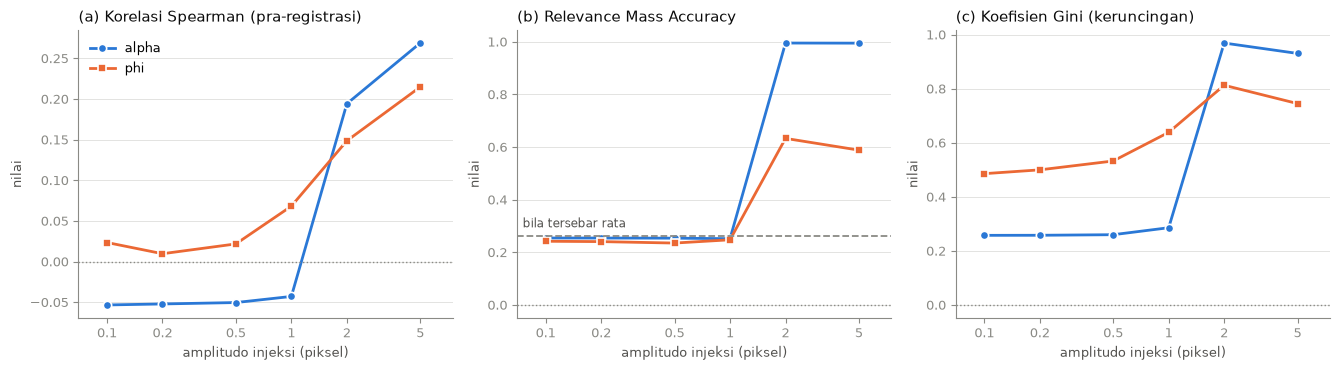

In [10]:
x = np.array(AMPLITUDO)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

for ax, kolom, judul in [(axes[0], "spearman", "(a) Korelasi Spearman (pra-registrasi)"),
                         (axes[1], "massa", "(b) Relevance Mass Accuracy"),
                         (axes[2], "gini", "(c) Koefisien Gini (keruncingan)")]:
    rapikan(ax); sumbu_amplitudo(ax, x)
    for besaran, warna, penanda in [("alpha", WARNA["biru"], "o"), ("phi", WARNA["jingga"], "s")]:
        nilai = [banding.loc[(A, besaran), kolom] for A in AMPLITUDO]
        ax.plot(x, nilai, "-", color=warna, marker=penanda,
                markeredgecolor="white", markeredgewidth=1.2, label=besaran)
    if kolom == "massa":
        netral = float(banding.massa_bila_rata.median())
        ax.axhline(netral, color=WARNA["netral"], ls="--", lw=1.3)
        ax.annotate("bila tersebar rata", xy=(x[0] * 0.75, netral), xytext=(0, 6),
                    textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
    ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
    ax.set_title(judul, loc="left"); ax.set_ylabel("nilai")
axes[0].legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

### Gambar 4 — Peta phi terhadap lokasi injeksi yang sebenarnya

Sejajar dengan Gambar 3 pada notebook Skenario S1, namun untuk phi. Perbedaan bentuk antara keduanya
adalah bukti langsung mengenai seberapa berbeda kedua besaran ini memandang rekaman yang sama.

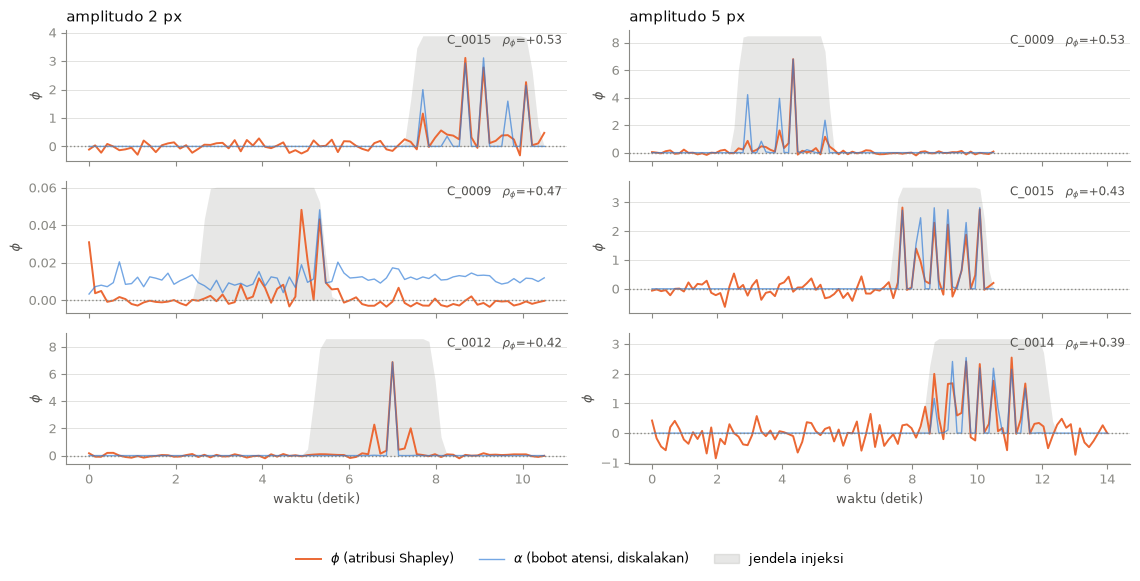

In [11]:
tampil = [A for A in AMPLITUDO if A >= 2.0][:2]
fig, axes = plt.subplots(3, len(tampil), figsize=(11.5, 5.6), sharex="col")
for kol, A in enumerate(tampil):
    urut = sorted(art_phi[A], key=lambda p: -spearmanr(p["phi"], p["acuan"]).statistic)[:3]
    for bar, p in enumerate(urut):
        ax = axes[bar, kol]; rapikan(ax)
        n = len(p["phi"]); waktu = np.arange(n) * P / FS
        skala = max(np.abs(p["phi"]).max(), 1e-12)
        ax.fill_between(waktu, 0, p["acuan"] * skala * 1.25, color=WARNA["netral"], alpha=0.20, lw=0)
        ax.plot(waktu, p["phi"], color=WARNA["jingga"], lw=1.4)
        ax.plot(waktu, p["alpha"] / max(p["alpha"].max(), 1e-12) * skala, color=WARNA["biru"],
                lw=1.0, alpha=0.65)
        ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
        r = spearmanr(p["phi"], p["acuan"]).statistic
        ax.annotate(f"{p['subjek']}   " + rf"$\rho_\phi$={r:+.2f}", xy=(0.99, 0.96),
                    xycoords="axes fraction", ha="right", va="top",
                    fontsize=8.5, color=TINTA["sekunder"])
        if bar == 0:
            ax.set_title(f"amplitudo {A:g} px", loc="left")
        if bar == 2:
            ax.set_xlabel("waktu (detik)")
        ax.set_ylabel(r"$\phi$", fontsize=9)
fig.legend(handles=[
    plt.Line2D([], [], color=WARNA["jingga"], lw=1.4, label=r"$\phi$ (atribusi Shapley)"),
    plt.Line2D([], [], color=WARNA["biru"], lw=1.0, alpha=0.65, label=r"$\alpha$ (bobot atensi, diskalakan)"),
    Rectangle((0, 0), 1, 1, color=WARNA["netral"], alpha=0.20, label="jendela injeksi"),
], loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04), fontsize=9)
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.show()

## 5. Rekalibrasi ambang keselarasan dengan phi

Rumusnya tidak berubah dari Subbab 3.6.7; hanya besarannya yang diganti menjadi phi, sebagaimana
memang dituntut analisis primer.

```
rho_lantai = korelasi pada kondisi tanpa sinyal (distribusi nol)
rho_atap   = korelasi saat sinyal sintetis beramplitudo besar berhasil dipulihkan
Ambang     = rho_lantai + 0,5 x (rho_atap - rho_lantai)
```

In [12]:
def distribusi_nol(peta, kunci, n_geser=50, seed=0):
    rng = np.random.default_rng(seed); keluar = []
    for p in peta:
        v, a = p[kunci], p["acuan"]
        n = len(v)
        if n < 3 or np.std(a) == 0 or np.std(v) == 0:
            continue
        for _ in range(n_geser):
            keluar.append(spearmanr(np.roll(v, int(rng.integers(1, n))), a).statistic)
    return np.array(keluar)

kalib = {}
for kunci in ["alpha", "phi"]:
    nol = np.concatenate([distribusi_nol(art_phi[A], kunci) for A in AMPLITUDO])
    lantai = float(np.median(nol))
    atap = float(max(np.median([spearmanr(p[kunci], p["acuan"]).statistic for p in art_phi[A]])
                     for A in AMPLITUDO))
    kalib[kunci] = {"rho_lantai": lantai, "rho_atap": atap,
                    "ambang": lantai + 0.5 * (atap - lantai), "nol": nol}

tabel = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "nol"} for k, v in kalib.items()}).T
display(tabel.round(4))
print(f"Ambang berbasis phi (dipakai analisis primer) = {kalib['phi']['ambang']:+.4f}")
print(f"Ambang berbasis alpha (sementara, dari S1)    = {kalib['alpha']['ambang']:+.4f}")

,rho_lantai,rho_atap,ambang
alpha,-0.0098,0.2689,0.1295
phi,-0.0088,0.2148,0.1030


Ambang berbasis phi (dipakai analisis primer) = +0.1030
Ambang berbasis alpha (sementara, dari S1)    = +0.1295


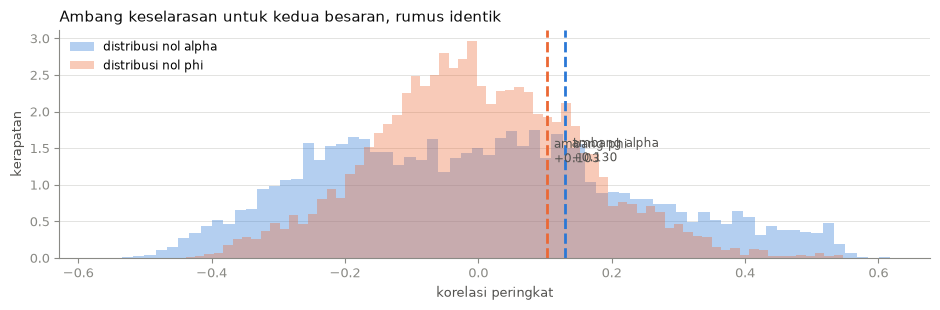

disimpan ke results/s6_kalibrasi_ambang.csv


In [13]:
fig, ax = plt.subplots(figsize=(9.5, 3.2)); rapikan(ax)
for kunci, warna in [("alpha", WARNA["biru"]), ("phi", WARNA["jingga"])]:
    ax.hist(kalib[kunci]["nol"], bins=70, density=True, alpha=0.35, lw=0, color=warna,
            label=f"distribusi nol {kunci}")
    ax.axvline(kalib[kunci]["ambang"], color=warna, ls="--", lw=2)
    ax.annotate(f"ambang {kunci}\n{kalib[kunci]['ambang']:+.3f}",
                xy=(kalib[kunci]["ambang"], ax.get_ylim()[1] * (0.72 if kunci == "alpha" else 0.42)),
                xytext=(5, 0), textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("korelasi peringkat"); ax.set_ylabel("kerapatan")
ax.set_title("Ambang keselarasan untuk kedua besaran, rumus identik", loc="left")
ax.legend(loc="upper left", fontsize=8.5)
plt.tight_layout(); plt.show()

pd.DataFrame([{
    "besaran": k, "rho_lantai": v["rho_lantai"], "rho_atap": v["rho_atap"], "ambang": v["ambang"],
    "patch_size": P, "epochs": EPOCHS, "seed": SEED, "n_koalisi": N_KOALISI,
    "strategi_latar": LATAR_UTAMA, "sumber": "notebooks/05_atribusi_shapley.ipynb",
} for k, v in kalib.items()]).to_csv(HASIL / "s6_kalibrasi_ambang.csv", index=False)
print(f"disimpan ke {HASIL.name}/s6_kalibrasi_ambang.csv")

## 6. Kesetiaan atensi: alpha terhadap phi

Pengukuran yang menjawab Rumusan Masalah 4, di sini pada kondisi terkendali dengan sinyal buatan
berlokasi diketahui. Nilainya bukan hasil akhir penelitian — itu baru diperoleh pada data pasien di
Skenario S6 — melainkan acuan atas seberapa besar kesetiaan yang mungkin dicapai ketika sinyalnya
justru paling jelas.

,kesetiaan_median,kuartil_25,kuartil_75,n
amplitudo_px,,,,
0.1,-0.193,-0.334,0.032,37
0.2,-0.211,-0.350,0.018,37
0.5,-0.217,-0.409,0.026,37
1.0,-0.228,-0.448,-0.030,37
2.0,0.111,0.023,0.156,37
5.0,0.203,0.138,0.227,37


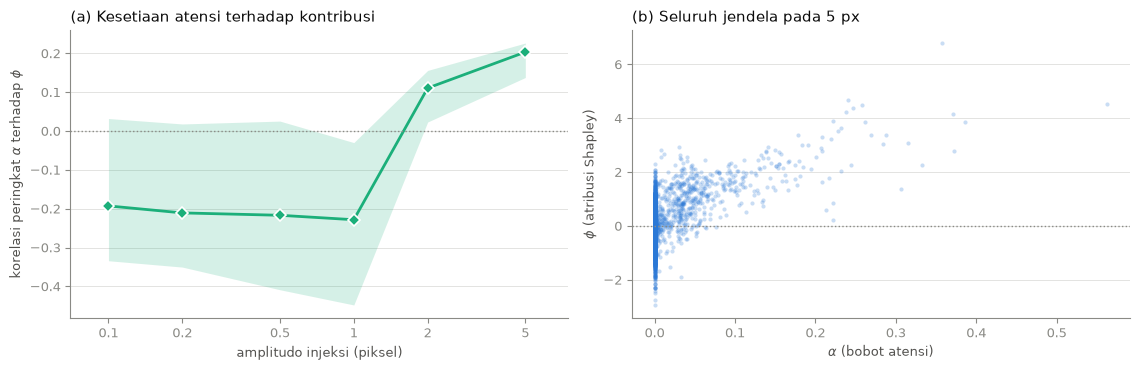

In [14]:
baris = []
for A in AMPLITUDO:
    nilai = [spearmanr(p["alpha"], p["phi"]).statistic for p in art_phi[A]
             if np.std(p["alpha"]) > 0 and np.std(p["phi"]) > 0]
    baris.append({"amplitudo_px": A, "kesetiaan_median": float(np.median(nilai)),
                  "kuartil_25": float(np.percentile(nilai, 25)),
                  "kuartil_75": float(np.percentile(nilai, 75)), "n": len(nilai)})
setia = pd.DataFrame(baris).set_index("amplitudo_px")
display(setia.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax = axes[0]; rapikan(ax); sumbu_amplitudo(ax, x)
ax.fill_between(x, setia.kuartil_25, setia.kuartil_75, color=WARNA["toska"], alpha=0.18, lw=0)
ax.plot(x, setia.kesetiaan_median, "-", color=WARNA["toska"], marker="D",
        markeredgecolor="white", markeredgewidth=1.2)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
ax.set_ylabel(r"korelasi peringkat $\alpha$ terhadap $\phi$")
ax.set_title("(a) Kesetiaan atensi terhadap kontribusi", loc="left")

ax = axes[1]; rapikan(ax)
A_besar = AMPLITUDO[-1]
xs = np.concatenate([p["alpha"] for p in art_phi[A_besar]])
ys = np.concatenate([p["phi"] for p in art_phi[A_besar]])
ax.scatter(xs, ys, s=9, alpha=0.25, color=WARNA["biru"], lw=0)
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
ax.set_xlabel(r"$\alpha$ (bobot atensi)"); ax.set_ylabel(r"$\phi$ (atribusi Shapley)")
ax.set_title(f"(b) Seluruh jendela pada {A_besar:g} px", loc="left")
plt.tight_layout(); plt.show()

## 7. Ringkasan

| Butir | Hasil |
|---|---|
| Pemulihan nilai eksak pada fungsi aditif | galat di bawah 1e-3, korelasi 1,000000 |
| Aksioma efisiensi | sisa nol, ditegakkan secara aljabar |
| Redundansi | menggerus besaran, **tidak** menggerus lokasi |
| Anggaran koalisi | 2048, kestabilan antar seed di atas 0,99 |
| Strategi latar | `nol` sebagai pilihan utama, `median_lokal` sebagai ablasi |
| Ambang keselarasan | dihitung ulang dengan phi, menggantikan angka sementara berbasis alpha |

**Yang berubah pada naskah.** Ambang keselarasan Subbab 3.6.7 kini berbasis phi sebagaimana memang
dituntut analisis primer. Angka berbasis alpha dari Skenario S1 tetap dilaporkan sebagai catatan
tahapan, bukan dihapus, agar jejak keputusannya terlihat.

**Batasan.**

1. Seluruh angka pada notebook ini diperoleh dari **data kontrol positif**, yaitu rekaman kontrol
   sehat dengan sinyal buatan. Nilainya menyatakan batas kemampuan pipeline pada kondisi paling
   menguntungkan, bukan hasil pada data pasien.
2. Kesetiaan alpha terhadap phi di sini juga terukur pada kondisi buatan. Rumusan Masalah 4 baru
   terjawab pada Skenario S6 dengan data pasien.
3. Ablasi strategi latar dijalankan pada satu tingkat amplitudo saja, untuk menekan biaya. Cukup
   untuk menguji ketergantungan kesimpulan pada acuan, tidak cukup untuk memetakan pengaruhnya
   secara menyeluruh.